In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [16]:
dataset = pd.read_csv('data/housing.csv')

In [7]:
dataset.head(4)

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt,Price
0,2126,4,1,Rural,1969,215355.283618
1,2459,3,2,Rural,1980,195014.221626
2,1860,2,1,Suburb,1970,306891.012076
3,2294,2,1,Urban,1996,206786.787153


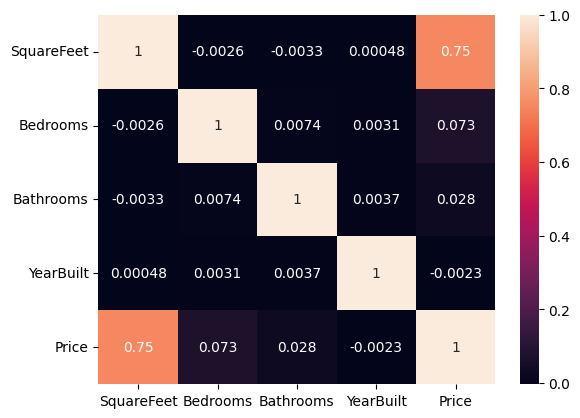

In [9]:
sns.heatmap(data = dataset.drop(columns=["Neighborhood"]).corr(), annot=True)
plt.show()

In [19]:
dataset["Neighborhood"].value_counts()

Neighborhood
1    16721
0    16676
2    16603
Name: count, dtype: int64

In [18]:
new_vals = {"Suburb":1, "Rural":0, "Urban":2}
dataset["Neighborhood"] = dataset["Neighborhood"].map(new_vals)

In [20]:
dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   SquareFeet    50000 non-null  int64  
 1   Bedrooms      50000 non-null  int64  
 2   Bathrooms     50000 non-null  int64  
 3   Neighborhood  50000 non-null  int64  
 4   YearBuilt     50000 non-null  int64  
 5   Price         50000 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 2.3 MB


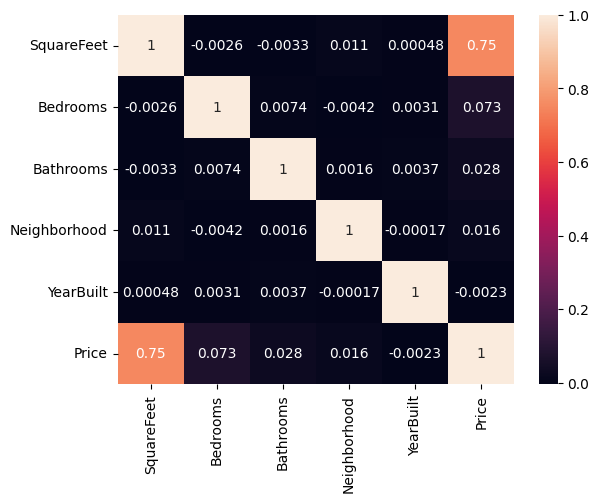

In [21]:
sns.heatmap(data = dataset.corr(), annot=True)
plt.show()

In [22]:
x = dataset.iloc[:,:-1]
y = dataset["Price"]

In [28]:
sc = StandardScaler()
sc.fit(x)
x = pd.DataFrame(sc.transform(x), columns=x.columns)
x.head()

,SquareFeet,Bedrooms,Bathrooms,Neighborhood,YearBuilt
0,0.207861,0.449067,-1.220113,-1.223957,-0.791751
1,0.786480,-0.446738,0.005614,-1.223957,-0.260842
2,-0.254340,-1.342543,-1.220113,0.001790,-0.743486
3,0.499777,-1.342543,-1.220113,1.227536,0.511390
4,0.214811,1.344872,0.005614,0.001790,0.752713


In [29]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [58]:
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error

### Linear Regression

In [ ]:
lr = LinearRegression()
lr.fit(x_train, y_train)
lr.score(x_test, y_test)

0.5754227349619043

In [61]:
print(mean_squared_error(y_test, lr.predict(x_test)))
print(mean_absolute_error(y_test, lr.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test, lr.predict(x_test))))

2437053699.8864026
39433.36167012688
49366.52408147046


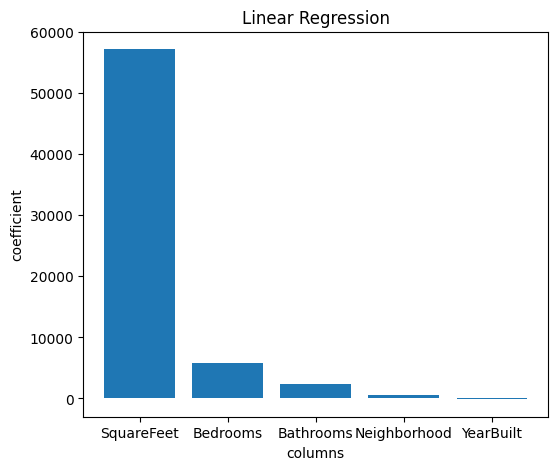

In [41]:
plt.figure(figsize=(6,5))
plt.bar(x.columns, lr.coef_)
plt.title("Linear Regression")
plt.xlabel("columns")
plt.ylabel("coefficient")
plt.show()

### L1 (Lasso)

In [66]:
la = Lasso(alpha=10)
la.fit(x_train, y_train)
la.score(x_test, y_test)

0.5754248428845303

In [67]:
print(mean_squared_error(y_test, la.predict(x_test)))
print(mean_absolute_error(y_test, la.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test, la.predict(x_test))))

2437041600.5088387
39433.38450817719
49366.40153493911


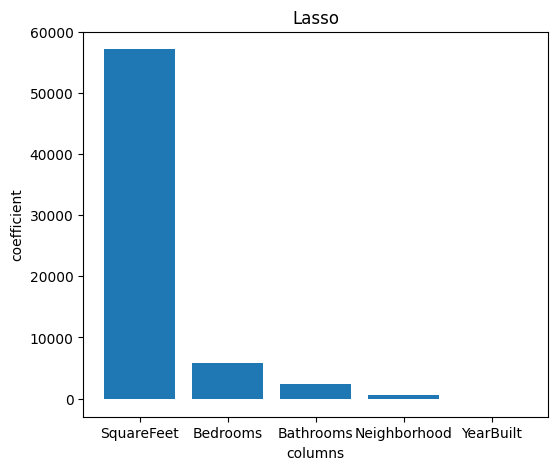

In [56]:
plt.figure(figsize=(6,5))
plt.bar(x.columns, la.coef_)
plt.title("Lasso")
plt.xlabel("columns")
plt.ylabel("coefficient")
plt.show()

### L2 (Ridge)

In [55]:
ri = Ridge(alpha = 10)
ri.fit(x_train, y_train)
ri.score(x_test, y_test)


0.5754232371603911

In [63]:
print(mean_squared_error(y_test, ri.predict(x_test)))
print(mean_absolute_error(y_test, ri.predict(x_test)))
print(np.sqrt(mean_squared_error(y_test, ri.predict(x_test))))

2437050817.2905097
39433.311328617274
49366.494885605454


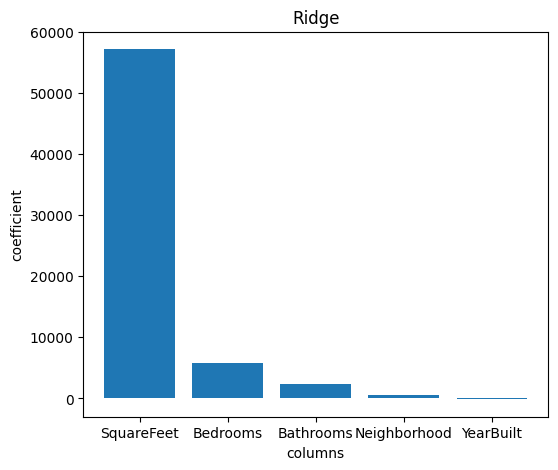

In [57]:
plt.figure(figsize=(6,5))
plt.bar(x.columns, ri.coef_)
plt.title("Ridge")
plt.xlabel("columns")
plt.ylabel("coefficient")
plt.show()

In [64]:
df = pd.DataFrame({"col_name":x.columns, "Linear Regression":lr.coef_, "Lasso":la.coef_, "Ridge":ri.coef_})

In [65]:
df

,col_name,Linear Regression,Lasso,Ridge
0,SquareFeet,57176.255252,57166.345724,57161.949171
1,Bedrooms,5840.215689,5830.108506,5838.739130
2,Bathrooms,2419.825626,2409.753409,2419.208643
3,Neighborhood,577.232468,567.257419,577.209317
4,YearBuilt,-121.336291,-111.294347,-121.348046
